<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/26032026_FINAL_WEAVE_SN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installation (execute only if running on a cloud platform!)¶

In [2]:
# -- Use the following line for google colab removing the hash at the beginning.
! pip install -q 'corner==2.2.2' 'bilby==2.2.2' 'astropy==6.0.1'

In [3]:
import os, glob
glob.glob("signalWEAVE*.tar.gz"), os.getcwd()

(['signalWEAVE.5.1.tar.gz'], '/content')

In [4]:
!tar -xvf signalWEAVE.5.1.tar.gz

._signalWEAVE
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
signalWEAVE
._signal2noise.py
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
signal2noise.py


In [5]:
!find . -maxdepth 3 -type f -name "signalWEAVE" -print

./signalWEAVE


In [6]:
!chmod +x ./signalWEAVE.5.1/signalWEAVE

chmod: cannot access './signalWEAVE.5.1/signalWEAVE': No such file or directory


In [7]:
!chmod +x ./signalWEAVE

In [8]:
!./signalWEAVE -h

usage: signalWEAVE [-h]
                   [--instrument_mode {blueLR,redLR,blueHR,greenHR,redHR}]
                   [--LIFU] [--sb] [--band {U,B,V,R,I}] [--X AIRMASS]
                   [--FWHM SEEING] [--profile {Moffat,Gaussian}]
                   [--betam BETAM] [--sky SKYSB] [--skyband {U,B,V,R,I}]
                   [--readnoise RN] [--dark DARK] [--offset OFFSET] [--rv]
                   mag time

Exposure time calculator for WEAVE.

positional arguments:
  mag                   Magnitude of object (defaults to point source
                        magnitude; if -sb switch is used, should be given as
                        mag/sq. arcsec
  time                  Exposure time in seconds

options:
  -h, --help            show this help message and exit
  --instrument_mode {blueLR,redLR,blueHR,greenHR,redHR}
                        VPH grating [default: blueLR]
  --LIFU                Fibre mode [default: MOS]
  --sb                  Surface brightness mode [default: False]
  --

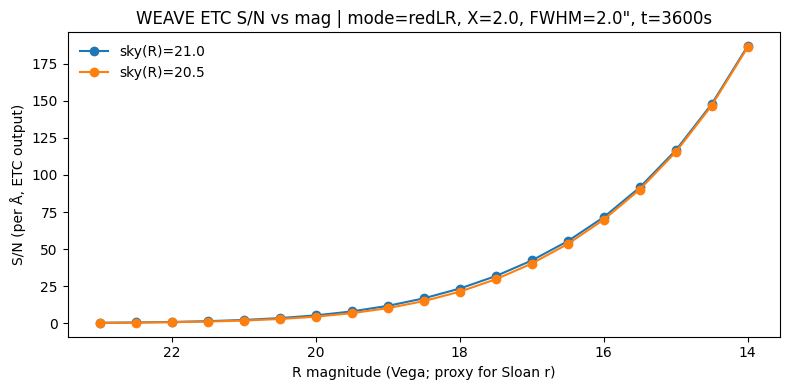

mag   S/N(sky=21.0)   S/N(sky=20.5)
14.0      186.80          186.04
14.5      147.72          146.78
15.0      116.52          115.37
15.5       91.55           90.16
16.0       71.51           69.86
16.5       55.37           53.48
17.0       42.35           40.27
17.5       31.84           29.69
18.0       23.44           21.36
18.5       16.83           14.97
19.0       11.77           10.23
19.5        8.03            6.84
20.0        5.36            4.49
20.5        3.52            2.91
21.0        2.28            1.87
21.5        1.46            1.19
22.0        0.93            0.76
22.5        0.59            0.48
23.0        0.38            0.30


In [9]:
import subprocess, re
import numpy as np
import matplotlib.pyplot as plt

SIGNAL = "./signalWEAVE"   # because it extracted into the current directory

# --- Settings requested ---
airmass = 2.0
seeing_fwhm = 2.0          # arcsec
exptime = 3600             # seconds
band = "R"                 # closest proxy to Sloan r
mode = "redLR"             # low-res red arm (good for redshift work)

# Sky brightness assumption in R, mag/arcsec^2 (between sky lines)
# Dark-ish R ~ 21.0; try 20.5 as a "brighter sky" stress test
sky_R = 21.0
skyband = "R"

mags = np.arange(14, 23.5, 0.5)

def run_signalweave(mag, sky_val=21.0):
    cmd = [
        SIGNAL,
        "--instrument_mode", mode,
        "--band", band,
        "--X", str(airmass),
        "--FWHM", str(seeing_fwhm),
        "--sky", str(sky_val),
        "--skyband", skyband,
        str(mag),
        str(exptime),
    ]
    out = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)

    # Robust parse: look for "S/N" followed by a number
    m = re.search(r"S/N[^0-9]*([0-9]+(?:\.[0-9]+)?)", out)
    if m:
        return float(m.group(1)), out

    # Fallback: last float on last non-empty line
    lines = [ln.strip() for ln in out.splitlines() if ln.strip()]
    floats = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", lines[-1]) if lines else []
    if floats:
        return float(floats[-1]), out

    raise RuntimeError(f"Could not parse S/N for mag={mag}.\nOutput head:\n{out[:400]}")

# --- Generate curve(s) ---
sn_dark = []
for mag in mags:
    sn, _ = run_signalweave(mag, sky_val=sky_R)
    sn_dark.append(sn)
sn_dark = np.array(sn_dark)

# Optional "brighter sky" scenario
sn_bright = []
for mag in mags:
    sn, _ = run_signalweave(mag, sky_val=20.5)
    sn_bright.append(sn)
sn_bright = np.array(sn_bright)

# --- Plot ---
plt.figure(figsize=(8,4))
plt.plot(mags, sn_dark, marker="o", label=f"sky(R)={sky_R}")
plt.plot(mags, sn_bright, marker="o", label="sky(R)=20.5")
plt.gca().invert_xaxis()
plt.xlabel("R magnitude (Vega; proxy for Sloan r)")
plt.ylabel("S/N (per Å, ETC output)")
plt.title(f"WEAVE ETC S/N vs mag | mode={mode}, X={airmass}, FWHM={seeing_fwhm}\", t={exptime}s")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Print a quick reference table for proposal text
print("mag   S/N(sky=21.0)   S/N(sky=20.5)")
for m, s1, s2 in zip(mags, sn_dark, sn_bright):
    print(f"{m:4.1f}     {s1:7.2f}         {s2:7.2f}")

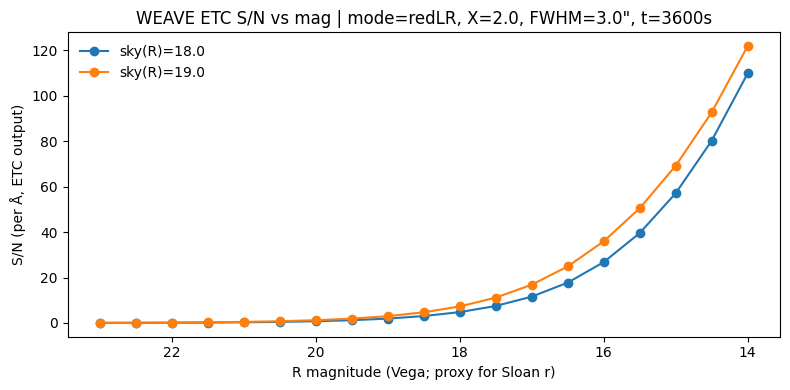

mag   S/N(sky=18.0)   S/N(sky=19.0)
14.0      109.84          121.86
14.5       80.21           92.69
15.0       57.09           69.21
15.5       39.58           50.51
16.0       26.79           35.93
16.5       17.77           24.90
17.0       11.60           16.85
17.5        7.49           11.17
18.0        4.80            7.29
18.5        3.06            4.71
19.0        1.94            3.01
19.5        1.23            1.92
20.0        0.78            1.22
20.5        0.49            0.77
21.0        0.31            0.49
21.5        0.20            0.31
22.0        0.12            0.19
22.5        0.08            0.12
23.0        0.05            0.08


In [10]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

SIGNAL = "./signalWEAVE"   # because it extracted into the current directory

# --- Settings requested ---
airmass = 2.0
seeing_fwhm = 3.0          # arcsec
exptime = 3600             # seconds
band = "R"                 # closest proxy to Sloan r
mode = "redLR"             # low-res red arm (good for redshift work)

# Sky brightness scenarios in R, mag/arcsec^2
sky_scenarios = [18.0, 19.0]
skyband = "R"

mags = np.arange(14, 23.5, 0.5)

def run_signalweave(mag, sky_val):
    cmd = [
        SIGNAL,
        "--instrument_mode", mode,
        "--band", band,
        "--X", str(airmass),
        "--FWHM", str(seeing_fwhm),
        "--sky", str(sky_val),
        "--skyband", skyband,
        str(mag),
        str(exptime),
    ]

    out = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)

    # Robust parse: look for "S/N" followed by a number
    m = re.search(r"S/N[^0-9]*([0-9]+(?:\.[0-9]+)?)", out)
    if m:
        return float(m.group(1)), out

    # Fallback: last float on last non-empty line
    lines = [ln.strip() for ln in out.splitlines() if ln.strip()]
    floats = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", lines[-1]) if lines else []
    if floats:
        return float(floats[-1]), out

    raise RuntimeError(f"Could not parse S/N for mag={mag}, sky={sky_val}.\nOutput head:\n{out[:400]}")

# --- Generate curves ---
sn_results = {}

for sky in sky_scenarios:
    sn_list = []
    for mag in mags:
        sn, _ = run_signalweave(mag, sky_val=sky)
        sn_list.append(sn)
    sn_results[sky] = np.array(sn_list)

# --- Plot ---
plt.figure(figsize=(8, 4))

for sky in sky_scenarios:
    plt.plot(mags, sn_results[sky], marker="o", label=f"sky(R)={sky:.1f}")

plt.gca().invert_xaxis()
plt.xlabel("R magnitude (Vega; proxy for Sloan r)")
plt.ylabel("S/N (per Å, ETC output)")
plt.title(f"WEAVE ETC S/N vs mag | mode={mode}, X={airmass}, FWHM={seeing_fwhm}\", t={exptime}s")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Print quick reference table ---
print("mag   S/N(sky=18.0)   S/N(sky=19.0)")
for i, mag in enumerate(mags):
    s18 = sn_results[18.0][i]
    s19 = sn_results[19.0][i]
    print(f"{mag:4.1f}     {s18:7.2f}         {s19:7.2f}")

/tmp/ipykernel_8532/1208227642.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


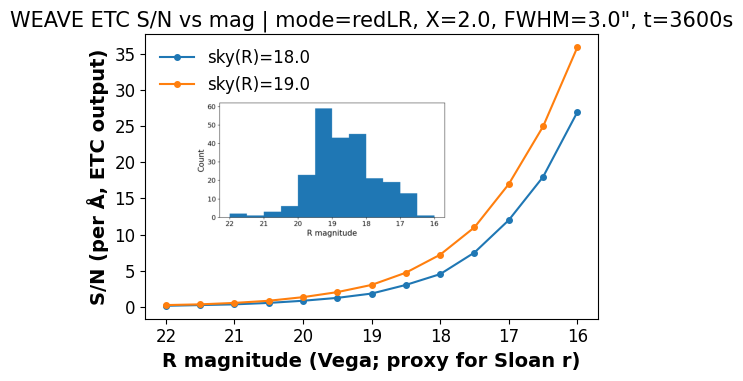

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# -----------------------
# Example data (replace with your real data)
# -----------------------
mags = np.arange(16, 22.5, 0.5)

sn_18 = np.array([27, 18, 12, 7.5, 4.5, 3.0, 1.8, 1.2, 0.8, 0.5, 0.3, 0.2, 0.1])
sn_19 = np.array([36, 25, 17, 11, 7.2, 4.7, 3.0, 2.0, 1.3, 0.8, 0.5, 0.3, 0.2])

# -----------------------
# Styling
# -----------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(5.5, 4))

# -----------------------
# Main plot
# -----------------------
ax.plot(mags, sn_18, marker="o", markersize=4, label="sky(R)=18.0")
ax.plot(mags, sn_19, marker="o", markersize=4, label="sky(R)=19.0")

ax.invert_xaxis()

ax.set_xlabel("R magnitude (Vega; proxy for Sloan r)", fontweight='bold')
ax.set_ylabel("S/N (per Å, ETC output)", fontweight='bold')

ax.set_title("WEAVE ETC S/N vs mag | mode=redLR, X=2.0, FWHM=3.0\", t=3600s")

ax.legend(frameon=False)

# -----------------------
# Inset image (robust version)
# -----------------------
ax_inset = fig.add_axes([0.23, 0.33, 0.46, 0.44])  # tweak if needed

img = mpimg.imread("hist.png")
ax_inset.imshow(img)
ax_inset.axis("off")

# Match background
ax_inset.set_facecolor(ax.get_facecolor())

# -----------------------
# Final
# -----------------------
plt.tight_layout()
plt.show()

/tmp/ipykernel_8532/1454663211.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


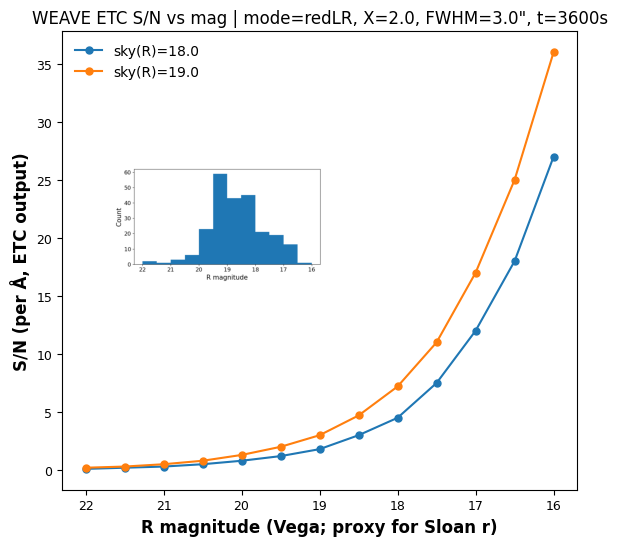

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

fig, ax = plt.subplots(figsize=(6.0, 5.6))

ax.plot(mags, sn_18, marker="o", markersize=5, label="sky(R)=18.0")
ax.plot(mags, sn_19, marker="o", markersize=5, label="sky(R)=19.0")

ax.invert_xaxis()

ax.set_xlabel("R magnitude (Vega; proxy for Sloan r)", fontweight="bold")
ax.set_ylabel("S/N (per Å, ETC output)", fontweight="bold")
ax.set_title('WEAVE ETC S/N vs mag | mode=redLR, X=2.0, FWHM=3.0", t=3600s')

ax.legend(frameon=False, loc="upper left")

# inset: left, bottom, width, height
ax_inset = fig.add_axes([0.20, 0.46, 0.35, 0.25])
img = mpimg.imread("hist.png")
ax_inset.imshow(img)
ax_inset.axis("off")
ax_inset.set_facecolor(ax.get_facecolor())

plt.tight_layout()
plt.show()

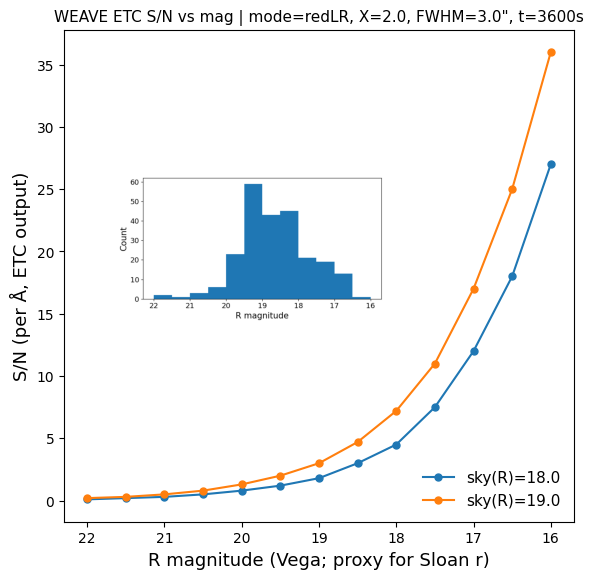

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, ax = plt.subplots(figsize=(6, 6))

# Manually control margins instead of tight_layout
fig.subplots_adjust(left=0.12, right=0.97, bottom=0.12, top=0.94)

# Main curves
ax.plot(mags, sn_18, marker="o", markersize=5, label="sky(R)=18.0")
ax.plot(mags, sn_19, marker="o", markersize=5, label="sky(R)=19.0")

ax.invert_xaxis()

ax.set_xlabel("R magnitude (Vega; proxy for Sloan r)")
ax.set_ylabel("S/N (per Å, ETC output)")
ax.set_title('WEAVE ETC S/N vs mag | mode=redLR, X=2.0, FWHM=3.0", t=3600s')

# Match proposal legend placement
ax.legend(frameon=False, loc="lower right")

# Inset image: [left, bottom, width, height]
ax_inset = fig.add_axes([0.19, 0.45, 0.48, 0.25])

img = mpimg.imread("hist.png")
ax_inset.imshow(img)
ax_inset.axis("off")
ax_inset.set_facecolor(ax.get_facecolor())

plt.show()

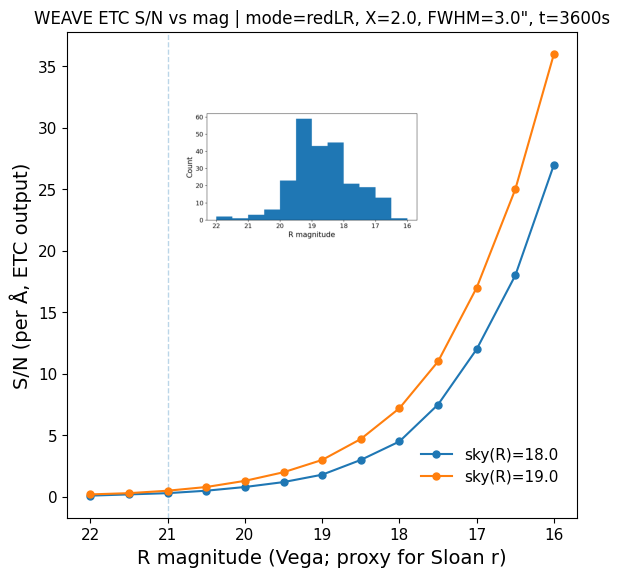

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, ax = plt.subplots(figsize=(6, 6))

# Margins: slightly more top room
fig.subplots_adjust(left=0.12, right=0.97, bottom=0.12, top=0.93)

# Main curves
ax.plot(mags, sn_18, marker="o", markersize=5, label="sky(R)=18.0")
ax.plot(mags, sn_19, marker="o", markersize=5, label="sky(R)=19.0")

ax.invert_xaxis()

ax.set_xlabel("R magnitude (Vega; proxy for Sloan r)")
ax.set_ylabel("S/N (per Å, ETC output)")
ax.set_title('WEAVE ETC S/N vs mag | mode=redLR, X=2.0, FWHM=3.0", t=3600s')

# Legend nudged to match proposal
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(0.99, 0.04))

# Optional: match proposal dashed line
ax.axvline(21, linestyle="--", linewidth=1, alpha=0.3, color="tab:blue", zorder=0)

# Inset: slightly larger and slightly lower
ax_inset = fig.add_axes([0.30, 0.58, 0.42, 0.22])

img = mpimg.imread("hist.png")
ax_inset.imshow(img)
ax_inset.axis("off")
ax_inset.set_facecolor(ax.get_facecolor())

plt.show()

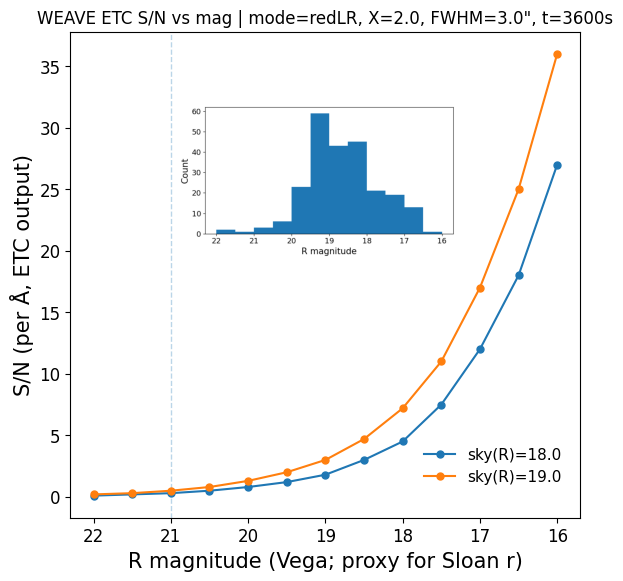

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# -----------------------
# USER DATA (replace if needed)
# -----------------------
# mags and S/N arrays should already exist from your ETC runs
# mags = np.arange(16, 22.5, 0.5)
# sn_18 = ...
# sn_19 = ...

# -----------------------
# GLOBAL STYLE (set BEFORE creating figure)
# -----------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# -----------------------
# FIGURE SETUP
# -----------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Control margins explicitly (avoid tight_layout conflicts)
fig.subplots_adjust(left=0.12, right=0.97, bottom=0.12, top=0.93)

# -----------------------
# MAIN S/N CURVES
# -----------------------
ax.plot(mags, sn_18, marker="o", markersize=5, label="sky(R)=18.0")
ax.plot(mags, sn_19, marker="o", markersize=5, label="sky(R)=19.0")

ax.invert_xaxis()

# Labels (force font size to actually apply)
ax.set_xlabel("R magnitude (Vega; proxy for Sloan r)", fontsize=15)
ax.set_ylabel("S/N (per Å, ETC output)", fontsize=15)
ax.set_title('WEAVE ETC S/N vs mag | mode=redLR, X=2.0, FWHM=3.0", t=3600s')

# Tick sizes (force override)
ax.tick_params(axis='both', labelsize=12)

# Legend (match proposal placement)
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(0.99, 0.04))

# Optional dashed line (keep/remove as you prefer)
ax.axvline(21, linestyle="--", linewidth=1, alpha=0.3, color="tab:blue", zorder=0)

# -----------------------
# INSET HISTOGRAM (IMAGE)
# -----------------------
# [left, bottom, width, height] in figure coordinates
ax_inset = fig.add_axes([0.29, 0.55, 0.48, 0.26])

img = mpimg.imread("hist.png")  # make sure this exists
ax_inset.imshow(img)
ax_inset.axis("off")

# Match background to main plot
ax_inset.set_facecolor(ax.get_facecolor())

# -----------------------
# SHOW
# -----------------------
plt.show()